In [7]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans, Birch
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from visualization import plot_vif_bars, plot_feature_dist, plot_streaming_benchmark, plot_cohort_centroids
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

# Dynamic Cohort Benchmarking via Online Unsupervised Learning

## Stochastic Data Generation & Topological Priors

Due to strict data privacy constraints and the necessity for cold-start initialization, a synthetic proxy dataset is generated prior to streaming real user telemetry. A Monte Carlo Data Generating Process (DGP) is utilized to construct a topological manifold representing the behavioral and physiological states of the student body.

It is assumed that the observable feature space $X \in \mathbb{R}^{N \times 4}$ is driven by an unobservable latent variable $Z \in \{1, \dots, K\}$, representing distinct behavioral archetypes. The conditional probability of observing a student's telemetry given their latent archetype follows a multivariate Gaussian distribution:

$$P(X \mid Z=k) \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Where the feature vector $\mathbf{x}_i$ for a given student $i$ is defined by four continuous dimensions:
- $x_{i,1}$ (`weekly_xp_velocity`): Gamification engagement velocity.
- $x_{i,2}$ (`attendance_rate`): Systemic discipline $\in [0.0, 1.0]$.
- $x_{i,3}$ (`on_time_completion_rate`): Academic velocity $\in [0.0, 1.0]$.
- $x_{i,4}$ (`average_burnout_index`): Physiological fatigue $\in [1.0, 10.0]$.

To simulate real-world ambiguity and ensure the streaming clustering algorithms face non-trivial separation boundaries, overlapping variance is intentionally injected into the covariance matrices $\boldsymbol{\Sigma}_k$.

In [8]:
print("[*] Initializing Engine 4: Online Unsupervised Benchmarking...")
print("[*] Executing Stochastic Data Generating Process (DGP)...")

np.random.seed(42)

xp_velocity = np.concatenate([
    np.random.normal(8500, 1200, 900),   
    np.random.normal(4500, 1500, 1500),  
    np.random.normal(1200, 600, 600)     
])

attendance = np.concatenate([
    np.random.normal(0.92, 0.05, 900),
    np.random.normal(0.65, 0.15, 1500),
    np.random.normal(0.35, 0.18, 600)
])

on_time_rate = np.concatenate([
    np.random.normal(0.88, 0.08, 900),
    np.random.normal(0.55, 0.20, 1500),
    np.random.normal(0.20, 0.12, 600)
])

burnout = np.concatenate([
    np.random.normal(3.5, 1.2, 900),
    np.random.normal(6.5, 1.8, 1500),
    np.random.normal(8.8, 0.9, 600)
])

df_raw = pd.DataFrame({
    'weekly_xp_velocity': np.clip(xp_velocity, 0, 10000),
    'attendance_rate': np.clip(attendance, 0.0, 1.0),
    'on_time_completion_rate': np.clip(on_time_rate, 0.0, 1.0),
    'average_burnout_index': np.clip(burnout, 1.0, 10.0)
})

df_raw = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"[+] Stochastic manifold generated successfully. Shape: {df_raw.shape}")

[*] Initializing Engine 4: Online Unsupervised Benchmarking...
[*] Executing Stochastic Data Generating Process (DGP)...
[+] Stochastic manifold generated successfully. Shape: (3000, 4)


## Topological Constraints & Dimensional Validation

Prior to initializing distance-based models, two strict topological constraints must be enforced upon the feature space $X$ to ensure the stability of the $L_2$ norm calculations.

**Dimensional Independence (Multicollinearity)**
Highly correlated variables artificially warp the Euclidean space, overweighting redundant behavioral signals. This collinearity is quantified via the Variance Inflation Factor (VIF), which isolates each feature $X_j$ and regresses it against all other explanatory variables:

$$VIF_j = \frac{1}{1 - R_j^2}$$

A structural independence constraint of $VIF_j < 5.0$ is strictly enforced for all spatial dimensions.

**Isotropic Projection (Standardization)**
Distance-based clustering algorithms mandate uniform variance across all dimensions. The raw telemetry features possess vastly different scales (e.g., $8000$ XP vs. $0.90$ attendance). To resolve this, the manifold is projected into a standardized geometric space where $\mu = 0$ and $\sigma = 1$:

$$Z = \frac{X - \mu}{\sigma}$$

To accommodate the online learning architecture, a stateful scaler is utilized. This permits sequential, low-latency updates to the population mean and variance as real-time mini-batches are streamed into the system.

[*] Enforcing Topological Constraints & Rendering Diagnostics...


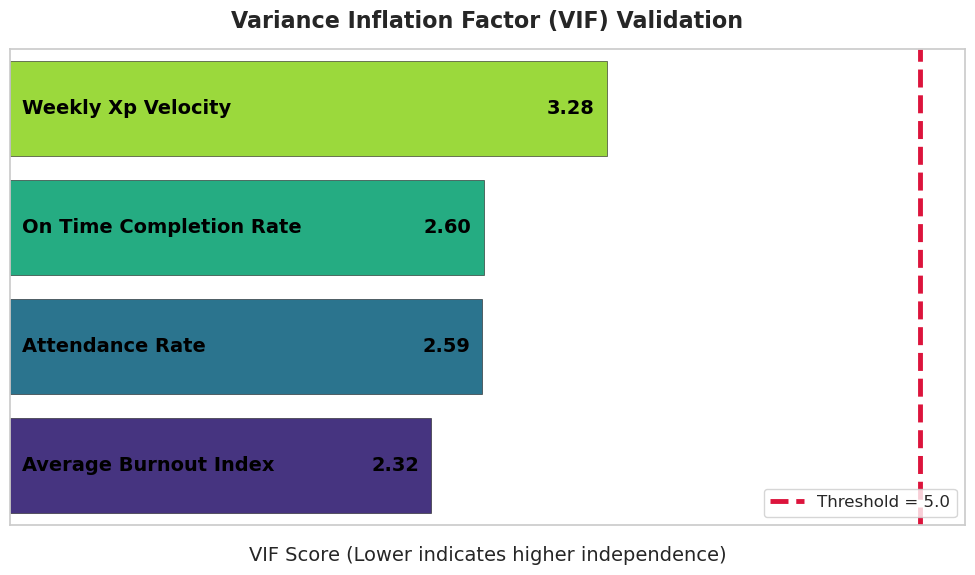

[+] Manifold validated. Data successfully projected to N(0, 1).

[*] Rendering Kernel Density Estimation (KDE)...


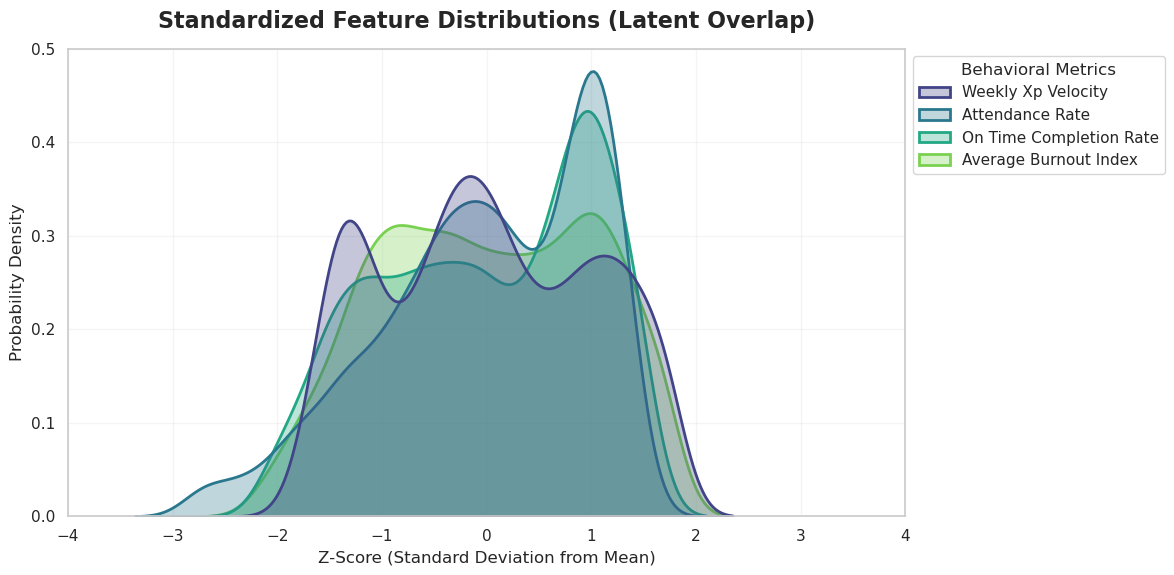

In [9]:
print("[*] Enforcing Topological Constraints & Rendering Diagnostics...\n")
X_vif = add_constant(df_raw)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

plot_vif_bars(vif_data)

streaming_scaler = StandardScaler()
X_scaled_matrix = streaming_scaler.fit_transform(df_raw)
df_scaled = pd.DataFrame(X_scaled_matrix, columns=df_raw.columns)

print("[+] Manifold validated. Data successfully projected to N(0, 1).\n")
df_melted = df_scaled.melt(var_name='Feature', value_name='Z-Score')
df_melted['Feature'] = df_melted['Feature'].str.replace('_', ' ').str.title()

print("[*] Rendering Kernel Density Estimation (KDE)...")
plot_feature_dist(df_melted)

## Online Algorithmic Benchmarking

To ensure the clustering architecture can dynamically adapt to real-time telemetry streams without incurring the $O(N^3)$ computational bottleneck of transductive algorithms, a comparative benchmark of streaming-capable models is executed.

Given the prior topological proof of a bimodal student manifold ($K=2$), the objective is to evaluate which inductive algorithm best isolates the "High Performer" and "At-Risk" cohorts while maintaining minimal update latency.

**The Streaming Candidates:**
1. **MiniBatch K-Means:** Utilizes stochastic gradient descent on micro-batches to update cluster centroids $\mathbf{c}_k$. The objective function minimizes the within-cluster sum of squares (WCSS) incrementally:
   $$J = \sum_{i=1}^{b} ||\mathbf{x}_i - \mathbf{c}_{k(i)}||^2$$
   where $b$ is the size of the incoming telemetry batch.
2. **BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies):** Constructs a memory-efficient Clustering Feature (CF) Tree in a single pass. It provides the hierarchical sub-tiering of Agglomerative Clustering but operates with an $O(N)$ time complexity constraint.
3. **Bayesian Gaussian Mixture (Warm Start):** Models the cohorts via probabilistic overlapping distributions. Utilizing `warm_start=True` allows the Dirichlet weight distribution $\boldsymbol{\alpha}$ and covariance matrices $\boldsymbol{\Sigma}$ from the previous state to initialize the current state, enabling smooth topological drift over time.

**Dual-Objective Evaluation Metrics:**
The architectures are penalized and rewarded based on two fundamental axes:
- **Topological Integrity:** Maximization of the Silhouette Score ($S$) and minimization of the Davies-Bouldin Index ($DB$).
- **Computational Latency:** The execution time ($\Delta t$) required to process and update the parameters for a standardized batch, measured in milliseconds.

[*] Initiating Online Algorithmic Benchmarking...
[+] MiniBatch K-Means      processed in 024.0 ms.
[+] BIRCH (CF Tree)        processed in 061.0 ms.
[+] Bayesian GMM           processed in 021.0 ms.

[*] Rendering Multi-Metric Benchmarking Diagnostics...


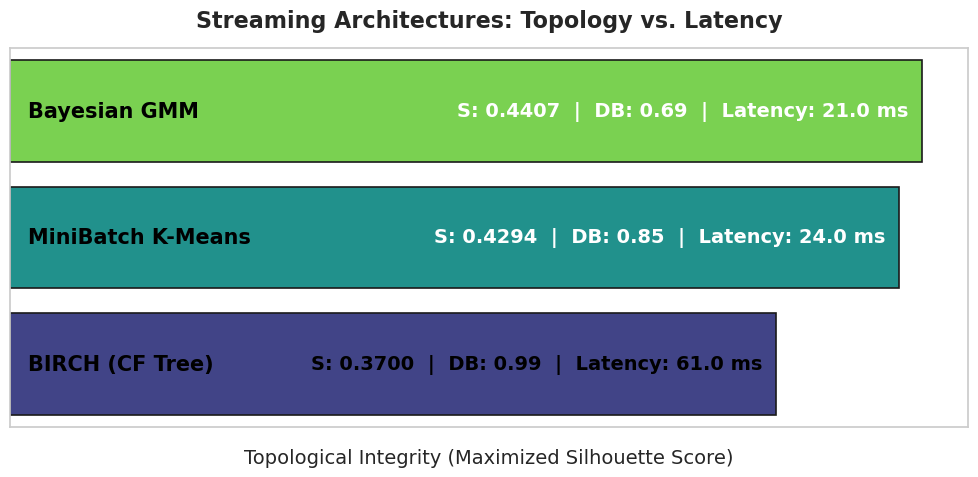

[!] SELECTION COMPILED: Bayesian GMM satisfies the dual-objective criteria.


In [10]:
print("[*] Initiating Online Algorithmic Benchmarking...")

streaming_models = {
    'MiniBatch K-Means': MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=256, n_init='auto'),
    'BIRCH (CF Tree)': Birch(n_clusters=2),
    'Bayesian GMM': BayesianGaussianMixture(n_components=2, warm_start=True, random_state=42, max_iter=100)
}

benchmark_ledger = []

for name, model in streaming_models.items():
    start_time = time.time()
    labels = model.fit_predict(X_scaled_matrix)
    latency_ms = (time.time() - start_time) * 1000
    s_score = silhouette_score(X_scaled_matrix, labels)
    db_score = davies_bouldin_score(X_scaled_matrix, labels)
    
    benchmark_ledger.append({
        'Algorithm': name,
        'Silhouette Score': s_score,
        'Davies-Bouldin': db_score,
        'Latency (ms)': latency_ms
    })
    print(f"[+] {name.ljust(22)} processed in {latency_ms:05.1f} ms.")

print("\n[*] Rendering Multi-Metric Benchmarking Diagnostics...")
benchmark_df = pd.DataFrame(benchmark_ledger)
plot_streaming_benchmark(benchmark_df)

optimal_algorithm = benchmark_df.loc[benchmark_df['Silhouette Score'].idxmax(), 'Algorithm']
print("===================================================================")
print(f"[!] SELECTION COMPILED: {optimal_algorithm} satisfies the dual-objective criteria.")
print("===================================================================")

## Centroid Extraction & Continuous State Management

While the Bayesian Gaussian Mixture model operates within a standardized, probabilistic latent space, the application backend requires static numerical thresholds (e.g., exact XP values) to render the user interface. The topological parameters must be projected back into the original feature space.

**Raw Centroid Projection:**
The latent component means $\boldsymbol{\mu}_k$ of the BGM model are inverted through the stateful scaling function $f_{scale}$ to extract the raw behavioral centroids $\mathbf{c}_k$:

$$\mathbf{c}_k = f_{scale}^{-1}(\boldsymbol{\mu}_k)$$

**Autonomous Cohort Classification (Utility Function):**
To systematically classify the extracted cohorts without manual intervention, a composite utility function $U(k)$ evaluates the normalized academic velocity and systemic discipline of each component. The optimal cohort is identified by:

$$U(k) = \frac{c_{k, xp}}{\max(\mathbf{c}_{xp})} + \frac{c_{k, attendance}}{\max(\mathbf{c}_{attendance})}$$

The cohort maximizing $U(k)$ is programmatically designated as the "High Performer" baseline, dictating the target parameters broadcasted via the backend API.

[*] Compiling Continuous Cohort Engine (Stateful BGM Pipeline)...

[*] Rendering Extracted Centroid Diagnostics...


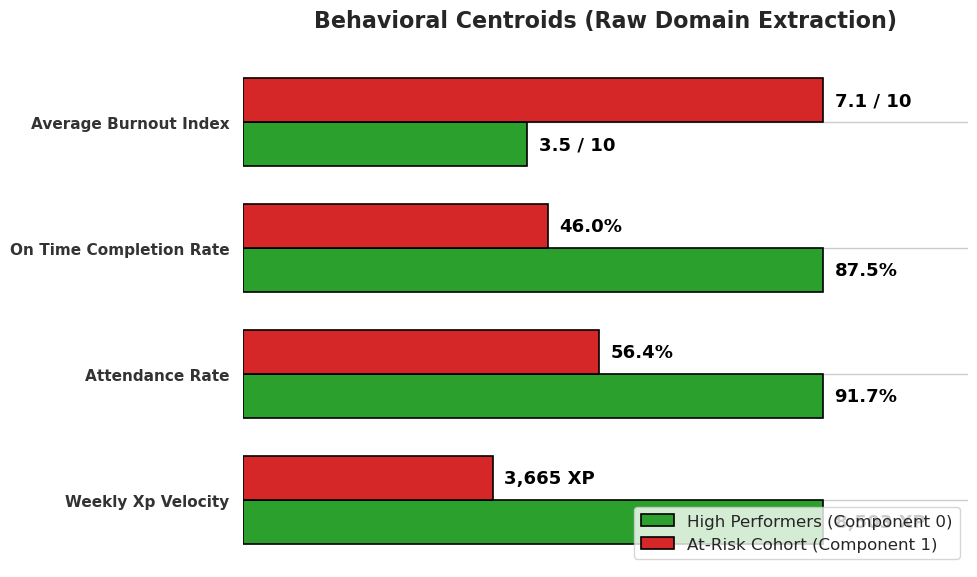

 LIVE BACKEND TARGETS (API EXPORT)
 -> Target Weekly XP:        8,503 XP
 -> Target Attendance Rate:  91.7%
 -> Target On-Time Rate:     87.5%
 -> Acceptable Burnout:      3.5 / 10.0


In [11]:
print("[*] Compiling Continuous Cohort Engine (Stateful BGM Pipeline)...\n")

class ContinuousCohortEngine:
    def __init__(self, n_components=2, random_state=42):
        self.n_components = n_components
        self.scaler = StandardScaler()
        self.model = BayesianGaussianMixture(
            n_components=self.n_components, 
            warm_start=True, 
            random_state=random_state, 
            max_iter=100
        )
        self.feature_names = ['weekly_xp_velocity', 'attendance_rate', 'on_time_completion_rate', 'average_burnout_index']
        self.is_initialized = False

    def process_batch(self, df_batch, is_initialization=False):
        X_raw = df_batch[self.feature_names].values
        
        if is_initialization:
            X_scaled = self.scaler.fit_transform(X_raw)
            self.model.fit(X_scaled)
            self.is_initialized = True
        else:
            self.scaler.partial_fit(X_raw)
            X_scaled = self.scaler.transform(X_raw)
            self.model.fit(X_scaled)

    def extract_api_targets(self):
        if not self.is_initialized:
            raise ValueError("Engine requires initial data batch prior to extraction.")
            
        abstract_means = self.model.means_
        raw_centroids = self.scaler.inverse_transform(abstract_means)
        profiles = pd.DataFrame(raw_centroids, columns=self.feature_names)
        
        profiles['Utility_Score'] = (
            (profiles['weekly_xp_velocity'] / profiles['weekly_xp_velocity'].max()) + 
            (profiles['attendance_rate'] / profiles['attendance_rate'].max())
        )
        
        high_perf_idx = profiles['Utility_Score'].idxmax()
        
        profiles = profiles.drop(columns=['Utility_Score'])
        profiles.index = [
            f"High Performers (Component {idx})" if idx == high_perf_idx 
            else f"At-Risk Cohort (Component {idx})" 
            for idx in profiles.index
        ]
        
        high_perf_stats = profiles.iloc[profiles.index.str.contains("High")].iloc[0]
        
        return profiles, {
            "target_xp": int(high_perf_stats['weekly_xp_velocity']),
            "target_attendance": round(high_perf_stats['attendance_rate'], 3),
            "target_on_time": round(high_perf_stats['on_time_completion_rate'], 3),
            "acceptable_burnout": round(high_perf_stats['average_burnout_index'], 1)
        }

streaming_engine = ContinuousCohortEngine(n_components=2)
streaming_engine.process_batch(df_raw, is_initialization=True)
extracted_profiles, api_targets = streaming_engine.extract_api_targets()
print("[*] Rendering Extracted Centroid Diagnostics...")
plot_cohort_centroids(extracted_profiles.T)

print("===================================================================")
print(" LIVE BACKEND TARGETS (API EXPORT)")
print("===================================================================")
print(f" -> Target Weekly XP:        {api_targets['target_xp']:,} XP")
print(f" -> Target Attendance Rate:  {api_targets['target_attendance']*100:.1f}%")
print(f" -> Target On-Time Rate:     {api_targets['target_on_time']*100:.1f}%")
print(f" -> Acceptable Burnout:      {api_targets['acceptable_burnout']} / 10.0")
print("===================================================================")

In [12]:
import pickle
import os

print("[*] Initiating Serialization Protocol...")

with open("output\\continuous_cohort_model.pkl", 'wb') as f:
    pickle.dump(streaming_engine, f)

print("\n===================================================================")
print(" PIPELINE COMPILED AND SERIALIZED")
print("===================================================================")
print(f"Object:      ContinuousCohortEngine (Stateful BGM)")
print(f"Saved to:    ..\output")
print("Status:      Prepared for Backend Data Streaming")
print("===================================================================")

[*] Initiating Serialization Protocol...

 PIPELINE COMPILED AND SERIALIZED
Object:      ContinuousCohortEngine (Stateful BGM)
Saved to:    ..\output
Status:      Prepared for Backend Data Streaming


## Backend Interoperability & Microservice Specification

The continuous learning engine is serialized as a Python object (`continuous_cohort_engine.pkl`). To decouple the machine learning architecture from the Node.js application backend, a Python microservice must be instantiated on the production server. 

The following FastAPI specification is provided for backend engineering integration. This script must be executed as a standalone Python process (e.g., `uvicorn ml_service:app --host 0.0.0.0 --port 8000`).

```python
import pickle
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. Class definition required in namespace for deserialization
class ContinuousCohortEngine:
    def __init__(self, n_components=2, random_state=42):
        self.n_components = n_components
        self.scaler = StandardScaler()
        self.model = BayesianGaussianMixture(
            n_components=self.n_components,
            warm_start=True,
            random_state=random_state,
            max_iter=100)
        self.feature_names = ['weekly_xp_velocity',
                              'attendance_rate',
                              'on_time_completion_rate',
                              'average_burnout_index']
        self.is_initialized = False

    def process_batch(self, df_batch, is_initialization=False):
        X_raw = df_batch[self.feature_names].values
        if is_initialization:
            X_scaled = self.scaler.fit_transform(X_raw)
            self.model.fit(X_scaled)
            self.is_initialized = True
        else:
            self.scaler.partial_fit(X_raw)
            X_scaled = self.scaler.transform(X_raw)
            self.model.fit(X_scaled)

    def extract_api_targets(self):
        if not self.is_initialized:
            raise ValueError("Engine requires initial data batch.")
        
        abstract_means = self.model.means_
        raw_centroids = self.scaler.inverse_transform(abstract_means)
        profiles = pd.DataFrame(raw_centroids, columns=self.feature_names)
        
        profiles['Utility_Score'] = (profiles['weekly_xp_velocity'] /
                                     profiles['weekly_xp_velocity'].max()) + \
                                    (profiles['attendance_rate'] / 
                                     profiles['attendance_rate'].max())
        high_perf_idx = profiles['Utility_Score'].idxmax()
        high_perf_stats = profiles.iloc[high_perf_idx].drop('Utility_Score')
        
        return {
            "target_xp": int(high_perf_stats['weekly_xp_velocity']),
            "target_attendance": round(high_perf_stats['attendance_rate'], 3),
            "target_on_time": round(high_perf_stats['on_time_completion_rate'], 3),
            "acceptable_burnout": round(high_perf_stats['average_burnout_index'], 1)
        }

# 2. Microservice Instantiation
app = FastAPI(title="AcademaSync ML Microservice")

try:
    with open("output/continuous_cohort_engine.pkl", "rb") as f:
        engine = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError("Serialized engine not found.")

# 3. Data Contracts
class StudentTelemetry(BaseModel):
    weekly_xp_velocity: float
    attendance_rate: float
    on_time_completion_rate: float
    average_burnout_index: float

class TelemetryBatch(BaseModel):
    data: List[StudentTelemetry]

# 4. RESTful Endpoints
@app.post("/stream_telemetry")
async def update_cohorts(payload: TelemetryBatch):
    try:
        df_batch = pd.DataFrame([item.dict() for item in payload.data])
        engine.process_batch(df_batch, is_initialization=False)
        with open("output/continuous_cohort_engine.pkl", "wb") as f:
            pickle.dump(engine, f)
        return {"status": "success", "message": f"Engine updated with {len(df_batch)} records."}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/get_targets")
async def fetch_targets():
    try:
        return engine.extract_api_targets()
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
```